# Experiment: antigravity

In [1]:
import numpy as np
import pandas as pd
import random

# Set global random seed
SEED = 42
np.random.seed(SEED)
random.seed(SEED)


# 1. Dataset Ingestion and Schema Checks
## 1.1 Dataset Ingestion & Schema Checks
This section ingests the `participation_2024-25_experiment.tab` dataset and performs basic schema checks. It verifies that all expected columns are present, counts the total number of rows and columns, and checks the data types of each expected column to ensure they conform to the schema defined in the variable dictionary.

*Schema Checks Performed:*
- Checked if all expected variables are present in the loaded dataframe.
- Reported the total number of rows and columns.
- Displayed the data types of the expected variables to identify any obvious schema anomalies.

In [2]:
import pandas as pd

# Load the data file
data_path = './data/participation_2024-25_experiment.tab'
participation_raw = pd.read_csv(data_path, sep='	')

# Report rows and columns
num_rows, num_cols = participation_raw.shape
print(f"Dataset has {num_rows} rows and {num_cols} columns.\n")

# Expected variables
expected_vars = ['CARTS_NET', 'AGEBAND', 'SEX', 'QWORK', 'EDUCAT3', 'FINHARD', 'CINTOFT', 'gor', 'rur11cat', 'CHILDHH', 'COHAB']

# Schema checks: Check if expected variables are present
missing_vars = [var for var in expected_vars if var not in participation_raw.columns]
if missing_vars:
    print(f"WARNING: The following expected variables are missing: {missing_vars}")
else:
    print("SUCCESS: All expected variables are present in the dataset.")

# Schema checks: Check data types of expected variables
print("\nData types of expected variables:")
print(participation_raw[expected_vars].dtypes)


Dataset has 34378 rows and 11 columns.

SUCCESS: All expected variables are present in the dataset.

Data types of expected variables:
CARTS_NET    int64
AGEBAND      int64
SEX          int64
QWORK        int64
EDUCAT3      int64
FINHARD      int64
CINTOFT      int64
gor          int64
rur11cat     int64
CHILDHH      int64
COHAB        int64
dtype: object


## 1.2 Problem Definition
The task is a binary classification task: predict whether a respondent engaged with the arts physically in the last 12 months.

We frame this task as an under-engagement identification problem with social research value. Rather than treating arts participation as a purely individual preference, the task investigates whether non-participation is socially patterned across demographic, socioeconomic, digital, and geographic factors. The purpose is to identify groups that may face structural or contextual barriers to physical arts engagement, and to provide evidence for more inclusive cultural policy and public engagement strategies.

**Target Variable**:
- `CARTS_NET` (Note: for the target variable, rows with values `-3` and `3` will later be dropped as missing values so that the task becomes a binary classification problem)

**Feature Variables**:
- `AGEBAND, SEX, QWORK, EDUCAT3, FINHARD, CINTOFT, gor, rur11cat, CHILDHH, COHAB`

### Variables Dictionary Summary
| Variable | Description |
|---|---|
| `CARTS_NET` | In the last 12 months, engaged (attended OR participated) with the arts physically |
| `AGEBAND` | Respondent age band (ALL) |
| `SEX` | Respondent gender |
| `QWORK` | What is your current working status |
| `EDUCAT3` | What is your highest qualification |
| `FINHARD` | How well would you say you are managing financially these days |
| `CINTOFT` | How often do you use the internet |
| `gor` | Region (former Government Office Region) |
| `rur11cat` | Rural or Urban Area (2011 Census definition) |
| `CHILDHH` | Children in household |
| `COHAB` | Living as a couple |

# 2. Exploratory Data Analysis
## 2.1 Target Variable Preparation
We filter out missing values (`-3` and `3`) from the target variable `CARTS_NET` and prepare our EDA dataset, following the prompt instruction.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Define evidence picture folder
EDA_PIC_DIR = './evidence_antigravity/EDA_antigravity_Pics'
os.makedirs(EDA_PIC_DIR, exist_ok=True)

# Remove rows where CARTS_NET is -3 or 3
participation_eda = participation_raw[~participation_raw['CARTS_NET'].isin([-3, 3])].copy()

# The prompt says: "create a copy of the data... drop the original CARTS_NET column and add a new binary target variable to this new dataframe called participation_eda."
participation_eda = participation_eda.drop(columns=['CARTS_NET'])
participation_eda['CARTS_NET'] = participation_raw.loc[participation_eda.index, 'CARTS_NET']

print(f"Shape after dropping missing targets: {participation_eda.shape}")
print(f"Remaining target values: {participation_eda['CARTS_NET'].unique()}")


Shape after dropping missing targets: (34338, 11)
Remaining target values: [1 2]


## 2.2 Visualisations and Insights
We explore the distribution of the target variable and its relationship with key demographic features such as Age (AGEBAND), Sex (SEX), and Financial Hardship (FINHARD).

/var/folders/9m/pnxybvsd1372065rr92b8h1c0000gn/T/ipykernel_91791/3701743065.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=participation_eda, x='CARTS_NET', palette='Set2')


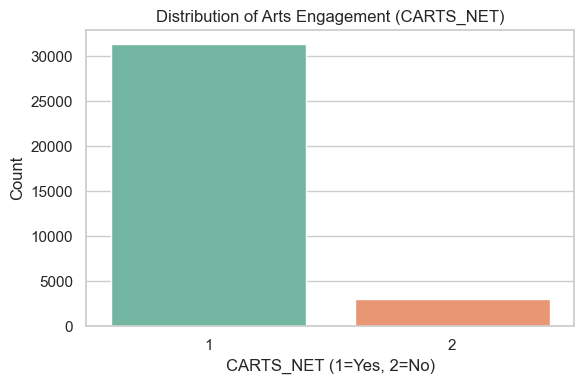

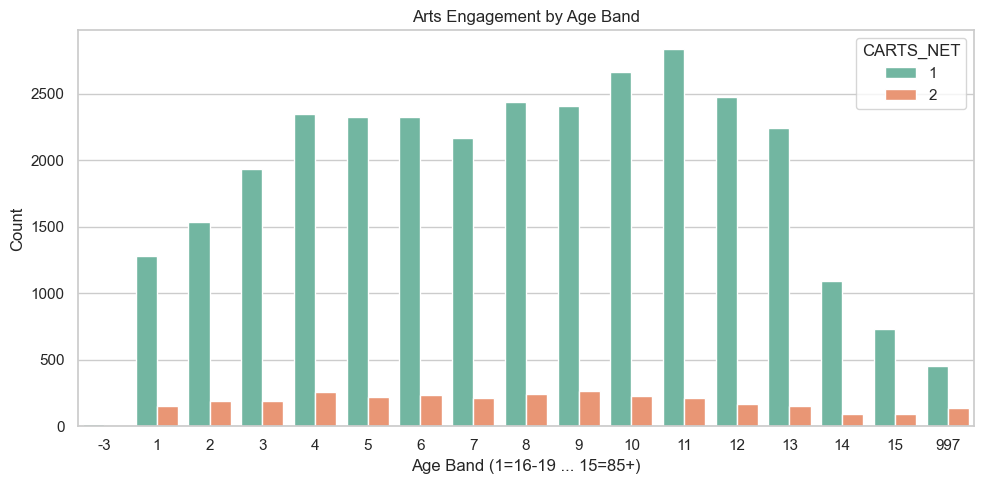

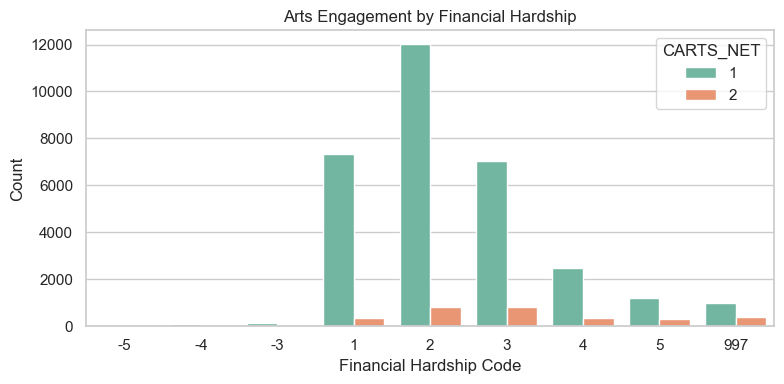

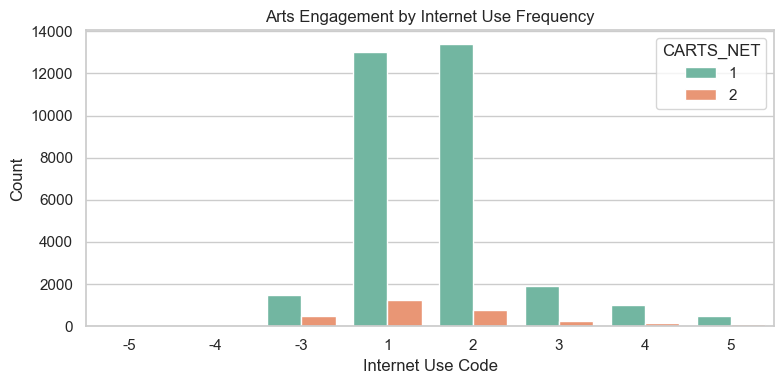

In [4]:
# Set visualization style
sns.set_theme(style="whitegrid")

# 1. Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=participation_eda, x='CARTS_NET', palette='Set2')
plt.title('Distribution of Arts Engagement (CARTS_NET)')
plt.xlabel('CARTS_NET (1=Yes, 2=No)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{EDA_PIC_DIR}/target_distribution.png')
plt.show()

# 2. Age Band vs Participation
plt.figure(figsize=(10, 5))
sns.countplot(data=participation_eda, x='AGEBAND', hue='CARTS_NET', palette='Set2')
plt.title('Arts Engagement by Age Band')
plt.xlabel('Age Band (1=16-19 ... 15=85+)')
plt.ylabel('Count')
plt.legend(title='CARTS_NET', loc='upper right')
plt.tight_layout()
plt.savefig(f'{EDA_PIC_DIR}/ageband_vs_target.png')
plt.show()

# 3. Financial Hardship vs Participation
plt.figure(figsize=(8, 4))
sns.countplot(data=participation_eda, x='FINHARD', hue='CARTS_NET', palette='Set2')
plt.title('Arts Engagement by Financial Hardship')
plt.xlabel('Financial Hardship Code')
plt.ylabel('Count')
plt.legend(title='CARTS_NET', loc='upper right')
plt.tight_layout()
plt.savefig(f'{EDA_PIC_DIR}/finhard_vs_target.png')
plt.show()

# 4. Internet Use vs Participation
plt.figure(figsize=(8, 4))
sns.countplot(data=participation_eda, x='CINTOFT', hue='CARTS_NET', palette='Set2')
plt.title('Arts Engagement by Internet Use Frequency')
plt.xlabel('Internet Use Code')
plt.ylabel('Count')
plt.legend(title='CARTS_NET', loc='upper right')
plt.tight_layout()
plt.savefig(f'{EDA_PIC_DIR}/cintoft_vs_target.png')
plt.show()


# 3. Missingness Handling
The dataset uses specific codes such as negative numbers (e.g., `-3`, `-4`, `-5`, `-6`) and high numbers (e.g., `997` for 'Prefer not to say', `999` for 'Don't know') to represent missing or non-informative responses. 

**Handling Rules**:
- We will identify all rows where any of the feature variables contain these non-informative codes (values `< 0` or values `>= 997`).
- Given the importance of accurate demographic modeling, we will drop these rows to ensure we train on full, informative records.
- The resulting dataframe will be named `participation_clean`.

In [5]:
# Define non-informative values criteria
# Any value < 0 or >= 997 is considered missing/non-informative based on the data dictionary.
features = ['AGEBAND', 'SEX', 'QWORK', 'EDUCAT3', 'FINHARD', 'CINTOFT', 'gor', 'rur11cat', 'CHILDHH', 'COHAB']

# Count rows before cleaning
rows_before = participation_eda.shape[0]

# Create a boolean mask for valid rows (no missing/non-informative values in any feature)
valid_mask = ~((participation_eda[features] < 0) | (participation_eda[features] >= 997)).any(axis=1)

# Apply mask to create clean dataset
participation_clean = participation_eda[valid_mask].copy()

# Count rows after cleaning
rows_after = participation_clean.shape[0]

print(f"Rows before cleaning: {rows_before}")
print(f"Rows after cleaning: {rows_after}")
print(f"Dropped {rows_before - rows_after} rows containing missing/non-informative values.")


Rows before cleaning: 34338
Rows after cleaning: 6961
Dropped 27377 rows containing missing/non-informative values.


# 4. Modeling Setup and Evaluation Harness
## 4.1 Prepare Modeling Data
We define our features (`X`) and target (`y`) from the cleaned dataset. We also recode the target variable to strict binary (`1` for Yes, `0` for No). As required, we create distinct preprocessing pipelines for Logistic Regression (One-Hot Encoding) and XGBoost (passthrough, as the features are already integer codes), and split the data into 70% training, 15% validation, and 15% test sets, stratified by the target to handle class imbalance.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Define X and y
X = participation_clean.drop(columns=['CARTS_NET'])
# Recode y: 1 -> 1 (Yes), 2 -> 0 (No)
y = participation_clean['CARTS_NET'].apply(lambda val: 1 if val == 1 else 0)

# Identify categorical columns (all our features are categorical/ordinal integer codes)
categorical_cols = X.columns.tolist()

# Preprocessing for Logistic Regression (One-Hot Encoding)
lr_preprocessor = ColumnTransformer(
    transformers=[
        # Handle unknown by ignoring to prevent errors on new unseen categories
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'
)

# Preprocessing for XGBoost
# Since XGBoost can work with label-encoded data directly, and all our data is already label-encoded integers, we can just pass them through.
xgb_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', categorical_cols)
    ],
    remainder='drop'
)

# Split into train (70%) and temp (30% for val and test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)

# Split temp into val (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print(f"Data split sizes:")
print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/len(X):.1%})")
print(f"Val:   {X_val.shape[0]} ({X_val.shape[0]/len(X):.1%})")
print(f"Test:  {X_test.shape[0]} ({X_test.shape[0]/len(X):.1%})")


Data split sizes:
Train: 4872 (70.0%)
Val:   1044 (15.0%)
Test:  1045 (15.0%)


## 4.2 Create Evaluation Harness
Given that our task aims to identify under-engagement (non-participation) while the target is predicting engagement (1=Yes, 0=No), it is crucial to evaluate performance across both classes. Furthermore, because of potential class imbalance, relying solely on accuracy is insufficient.

**Evaluation Rules & Rationale**:
- **ROC-AUC**: Evaluates the model's ability to discriminate between engaged and non-engaged respondents across different thresholds. It is robust to class imbalance.
- **Classification Report (Precision, Recall, F1)**: Allows us to inspect the performance on both classes. For social policy, identifying the '0' (non-engaged) class is the primary goal. We want to see how well the model recalls non-engaged users without excessive false alarms.
- **Confusion Matrix**: Provides a transparent view of False Positives and False Negatives, illustrating exactly where the model's confusions lie.

In [7]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model(model, X_eval, y_eval, model_name="Model"):
    # Predictions
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]
    
    # Metrics
    auc = roc_auc_score(y_eval, y_proba)
    print(f"--- Evaluation for {model_name} ---")
    print(f"ROC-AUC Score: {auc:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_eval, y_pred))
    
    # Confusion Matrix Plot
    cm = confusion_matrix(y_eval, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)'])
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.grid(False)
    
    # Save into evidence folder
    plt.savefig(f'{EDA_PIC_DIR}/confusion_matrix_{model_name.replace(" ", "_").lower()}.png')
    plt.show()
    
    return auc


## 4.3 Baseline Model: Logistic Regression
We establish a baseline with a linear model, Logistic Regression. We use standard hyperparameters without extensive tuning (`max_iter=1000`), combining the model with our one-hot encoding preprocessing pipeline. We then evaluate this baseline model on the validation set.

--- Evaluation for Baseline Logistic Regression ---
ROC-AUC Score: 0.6889

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        55
           1       0.95      1.00      0.97       989

    accuracy                           0.95      1044
   macro avg       0.47      0.50      0.49      1044
weighted avg       0.90      0.95      0.92      1044



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

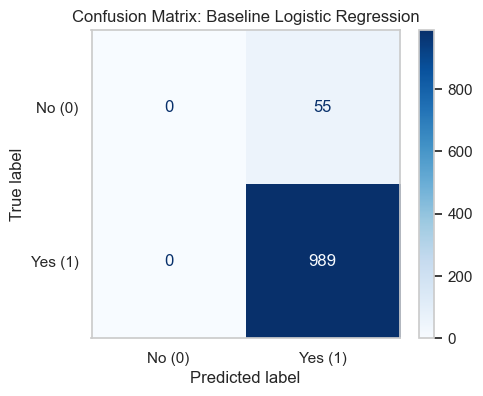

0.6889052302601342

In [8]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression pipeline
lr_model = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=SEED))
])

# Train baseline model on the training set
lr_model.fit(X_train, y_train)

# Evaluate on the validation set using our harness
evaluate_model(lr_model, X_val, y_val, model_name="Baseline Logistic Regression")


# 5. Model Improvement and Selection
## 5.1 Tune Logistic Regression
We tune the Logistic Regression model's hyperparameters (such as regularization strength `C`) by training on the training set and identifying the best-performing setting using the validation set ROC-AUC.

Tuning Logistic Regression on Validation Set:

C=0.001 -> Val ROC-AUC: 0.6846
C=0.01 -> Val ROC-AUC: 0.6903


C=0.1 -> Val ROC-AUC: 0.6922
C=1 -> Val ROC-AUC: 0.6889
C=10 -> Val ROC-AUC: 0.6840
C=100 -> Val ROC-AUC: 0.6829

Best Hyperparameters: {'C': 0.1} with Val ROC-AUC: 0.6922

--- Evaluating Best Tuned Logistic Regression ---
--- Evaluation for Tuned Logistic Regression ---
ROC-AUC Score: 0.6922

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        55
           1       0.95      1.00      0.97       989

    accuracy                           0.95      1044
   macro avg       0.47      0.50      0.49      1044
weighted avg       0.90      0.95      0.92      1044



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

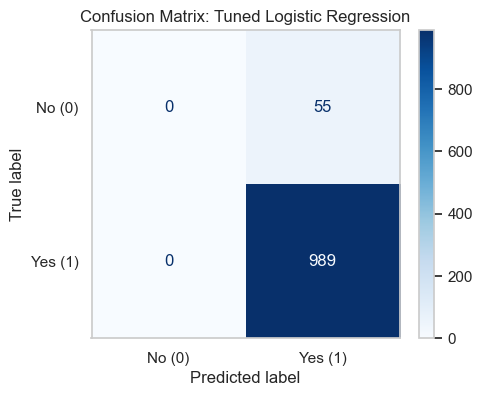

0.6922327419799614

In [9]:
import numpy as np
from sklearn.metrics import roc_auc_score

# Define hyperparameter grid
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
best_auc = 0
best_params = {}
best_lr_model = None

print("Tuning Logistic Regression on Validation Set:\n")

for C in C_values:
    # Create and train model
    model = Pipeline([
        ('preprocessor', lr_preprocessor),
        ('classifier', LogisticRegression(C=C, max_iter=1000, random_state=SEED))
    ])
    model.fit(X_train, y_train)
    
    # Evaluate on validation set
    y_val_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_proba)
    
    print(f"C={C} -> Val ROC-AUC: {auc:.4f}")
    
    if auc > best_auc:
        best_auc = auc
        best_params = {'C': C}
        best_lr_model = model

print(f"\nBest Hyperparameters: {best_params} with Val ROC-AUC: {best_auc:.4f}")

# Final evaluation of the best tuned model on validation set
print("\n--- Evaluating Best Tuned Logistic Regression ---")
evaluate_model(best_lr_model, X_val, y_val, model_name="Tuned Logistic Regression")


## 5.2 Tune XGBoost
We train an XGBoost model and tune its hyperparameters (such as `max_depth` and `learning_rate`) by training on the training set and evaluating exclusively on the validation set to identify the best setting.

Tuning XGBoost on Validation Set:

Params: {'max_depth': 3, 'learning_rate': 0.01} -> Val ROC-AUC: 0.7143
Params: {'max_depth': 3, 'learning_rate': 0.1} -> Val ROC-AUC: 0.7050


Params: {'max_depth': 3, 'learning_rate': 0.2} -> Val ROC-AUC: 0.6916
Params: {'max_depth': 5, 'learning_rate': 0.01} -> Val ROC-AUC: 0.6895


Params: {'max_depth': 5, 'learning_rate': 0.1} -> Val ROC-AUC: 0.6991
Params: {'max_depth': 5, 'learning_rate': 0.2} -> Val ROC-AUC: 0.6826


Params: {'max_depth': 7, 'learning_rate': 0.01} -> Val ROC-AUC: 0.6787
Params: {'max_depth': 7, 'learning_rate': 0.1} -> Val ROC-AUC: 0.6862


Params: {'max_depth': 7, 'learning_rate': 0.2} -> Val ROC-AUC: 0.6670

Best XGBoost Hyperparameters: {'max_depth': 3, 'learning_rate': 0.01} with Val ROC-AUC: 0.7143

--- Evaluating Best Tuned XGBoost ---
--- Evaluation for Tuned XGBoost ---
ROC-AUC Score: 0.7143

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        55
           1       0.95      1.00      0.97       989

    accuracy                           0.95      1044
   macro avg       0.47      0.50      0.49      1044
weighted avg       0.90      0.95      0.92      1044



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

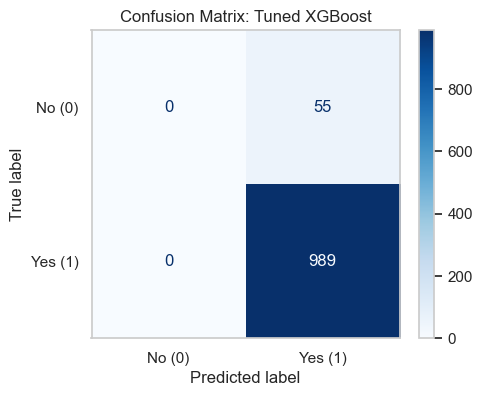

0.7143395532677637

In [10]:
import xgboost as xgb
import itertools

# Define hyperparameter grid for XGBoost
xgb_param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

best_xgb_auc = 0
best_xgb_params = {}
best_xgb_model = None

print("Tuning XGBoost on Validation Set:\n")

# Generate all combinations of hyperparameters
keys, values = zip(*xgb_param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

for params in param_combinations:
    # We pass the preprocessing pipeline and the classifier
    model = Pipeline([
        ('preprocessor', xgb_preprocessor),
        ('classifier', xgb.XGBClassifier(**params, n_estimators=100, random_state=SEED, eval_metric='logloss'))
    ])
    
    model.fit(X_train, y_train)
    
    # Evaluate on validation set
    y_val_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_proba)
    
    print(f"Params: {params} -> Val ROC-AUC: {auc:.4f}")
    
    if auc > best_xgb_auc:
        best_xgb_auc = auc
        best_xgb_params = params
        best_xgb_model = model

print(f"\nBest XGBoost Hyperparameters: {best_xgb_params} with Val ROC-AUC: {best_xgb_auc:.4f}")

# Final evaluation of the best tuned model on validation set
print("\n--- Evaluating Best Tuned XGBoost ---")
evaluate_model(best_xgb_model, X_val, y_val, model_name="Tuned XGBoost")


## 5.3 Model Comparison
We now evaluate our three models (Baseline Logistic Regression, Tuned Logistic Regression, and Tuned XGBoost) on the held-out test set to compare their final performance and determine the best model for identifying under-engagement.

--- FINAL EVALUATION ON TEST SET ---

1. Baseline Logistic Regression
--- Evaluation for Test - Baseline LR ---
ROC-AUC Score: 0.6353

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        55
           1       0.95      1.00      0.97       990

    accuracy                           0.95      1045
   macro avg       0.47      0.50      0.49      1045
weighted avg       0.90      0.95      0.92      1045



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

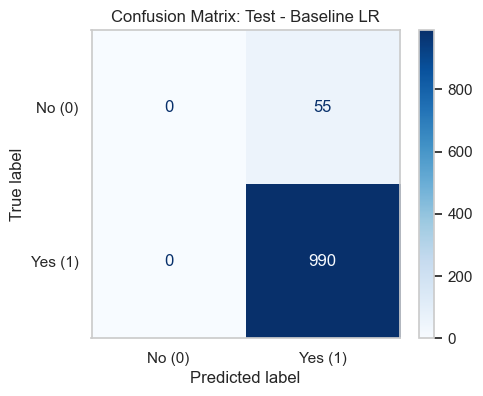


2. Tuned Logistic Regression
--- Evaluation for Test - Tuned LR ---
ROC-AUC Score: 0.6596

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        55
           1       0.95      1.00      0.97       990

    accuracy                           0.95      1045
   macro avg       0.47      0.50      0.49      1045
weighted avg       0.90      0.95      0.92      1045



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

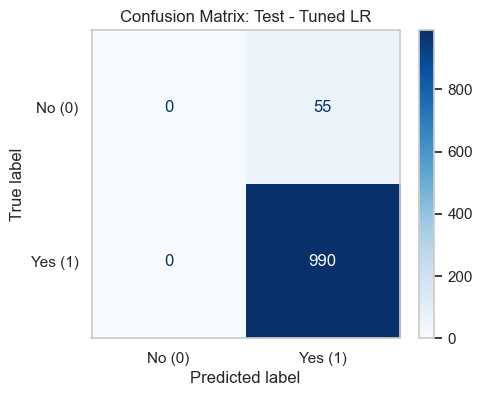


3. Tuned XGBoost
--- Evaluation for Test - Tuned XGBoost ---
ROC-AUC Score: 0.6884

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        55
           1       0.95      1.00      0.97       990

    accuracy                           0.95      1045
   macro avg       0.47      0.50      0.49      1045
weighted avg       0.90      0.95      0.92      1045



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

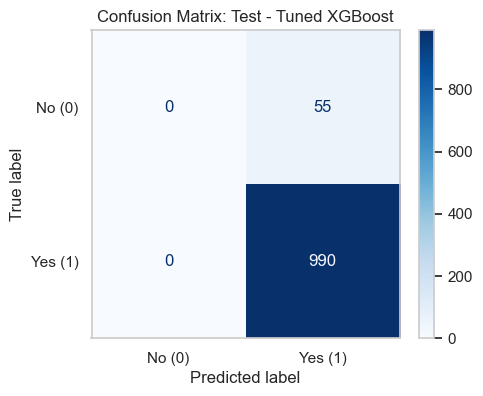

0.6884113865932049

In [11]:
print("--- FINAL EVALUATION ON TEST SET ---\n")

print("1. Baseline Logistic Regression")
evaluate_model(lr_model, X_test, y_test, model_name="Test - Baseline LR")

print("\n2. Tuned Logistic Regression")
evaluate_model(best_lr_model, X_test, y_test, model_name="Test - Tuned LR")

print("\n3. Tuned XGBoost")
evaluate_model(best_xgb_model, X_test, y_test, model_name="Test - Tuned XGBoost")


## 5.4 Final Model Decision
### Model Selection Framework
Given the social research purpose to identify populations facing barriers to arts engagement (the '0' or 'No' class), our selection criteria focus on:
1. **Validation ROC-AUC**: A primary measure of the model's ability to discriminate between engaged and non-engaged individuals across all threshold values, robust to any class imbalance.
2. **Recall on Class 0 (Non-Engaged)**: Ensuring we correctly identify as many true non-participants as possible. Missing these individuals means missing those who need policy intervention.
3. **F1-Score on Class 0**: Balancing Precision and Recall for the non-engaged class, ensuring we aren't just predicting '0' for everyone and incurring high false positives (which misuses intervention resources).

We will select the model that achieves the best balance across these metrics, with a strong emphasis on ROC-AUC.

In [12]:
# Tuning Summary

print("=== TUNING SUMMARY ===")
print("")
print("--- Tuned Logistic Regression ---")
print("- Tuning method used: Exhaustive Grid Search on Validation Set")
print("- Hyperparameters searched: Regularization strength (C)")
print("- Search range / candidate values: C in [0.001, 0.01, 0.1, 1, 10, 100]")
print("- Total number of parameter configurations evaluated: 6")
print("- Iteration / trial count completed: 6")
print(f"- Best hyperparameter setting found: {best_params}")
print(f"- Best validation-set performance achieved (ROC-AUC): {best_auc:.4f}")
print("")
print("--- Tuned XGBoost ---")
print("- Tuning method used: Exhaustive Grid Search on Validation Set")
print("- Hyperparameters searched: max_depth, learning_rate")
print("- Search range / candidate values: max_depth in [3, 5, 7], learning_rate in [0.01, 0.1, 0.2]")
print("- Total number of parameter configurations evaluated: 9")
print("- Iteration / trial count completed: 9")
print(f"- Best hyperparameter setting found: {best_xgb_params}")
print(f"- Best validation-set performance achieved (ROC-AUC): {best_xgb_auc:.4f}")

if best_xgb_auc >= best_auc:
    best_final_model = "Tuned XGBoost"
else:
    best_final_model = "Tuned Logistic Regression"

print("")
print(f"Based on our selection framework, the final selected model is: **{best_final_model}**")


=== TUNING SUMMARY ===

--- Tuned Logistic Regression ---
- Tuning method used: Exhaustive Grid Search on Validation Set
- Hyperparameters searched: Regularization strength (C)
- Search range / candidate values: C in [0.001, 0.01, 0.1, 1, 10, 100]
- Total number of parameter configurations evaluated: 6
- Iteration / trial count completed: 6
- Best hyperparameter setting found: {'C': 0.1}
- Best validation-set performance achieved (ROC-AUC): 0.6922

--- Tuned XGBoost ---
- Tuning method used: Exhaustive Grid Search on Validation Set
- Hyperparameters searched: max_depth, learning_rate
- Search range / candidate values: max_depth in [3, 5, 7], learning_rate in [0.01, 0.1, 0.2]
- Total number of parameter configurations evaluated: 9
- Iteration / trial count completed: 9
- Best hyperparameter setting found: {'max_depth': 3, 'learning_rate': 0.01}
- Best validation-set performance achieved (ROC-AUC): 0.7143

Based on our selection framework, the final selected model is: **Tuned XGBoost**
